## query expansion model's result analysis


Loading 12 result files...
  query_expansion_bge_mistral_v02_results.csv: 100 rows
  query_expansion_multiqa_mistral_v02_results.csv: 100 rows
  query_expansion_multiqa_phi2_results.csv: 100 rows
  query_expansion_multiqa_qwen_results.csv: 100 rows
  query_expansion_minilm_mistral_v01_results.csv: 100 rows
  query_expansion_minilm_mistral_v02_results.csv: 100 rows
  query_expansion_bge_phi2_results.csv: 100 rows
  query_expansion_minilm_phi2_results.csv: 100 rows
  query_expansion_bge_qwen_results.csv: 100 rows
  query_expansion_minilm_qwen_results.csv: 100 rows
  query_expansion_multiqa_mistral_v01_results.csv: 100 rows
  query_expansion_bge_mistral_v01_results.csv: 100 rows
Loaded 1200 total results
Configurations: 12



GENERATING COMPLETE ANALYSIS REPORT
Saved: results_analysis/query_expansion/summary_statistics.csv



................................................................................
ANSWER QUALITY ANALYSIS (sorted by Overall Score high to low)
Overall = 0.40 x Gen 

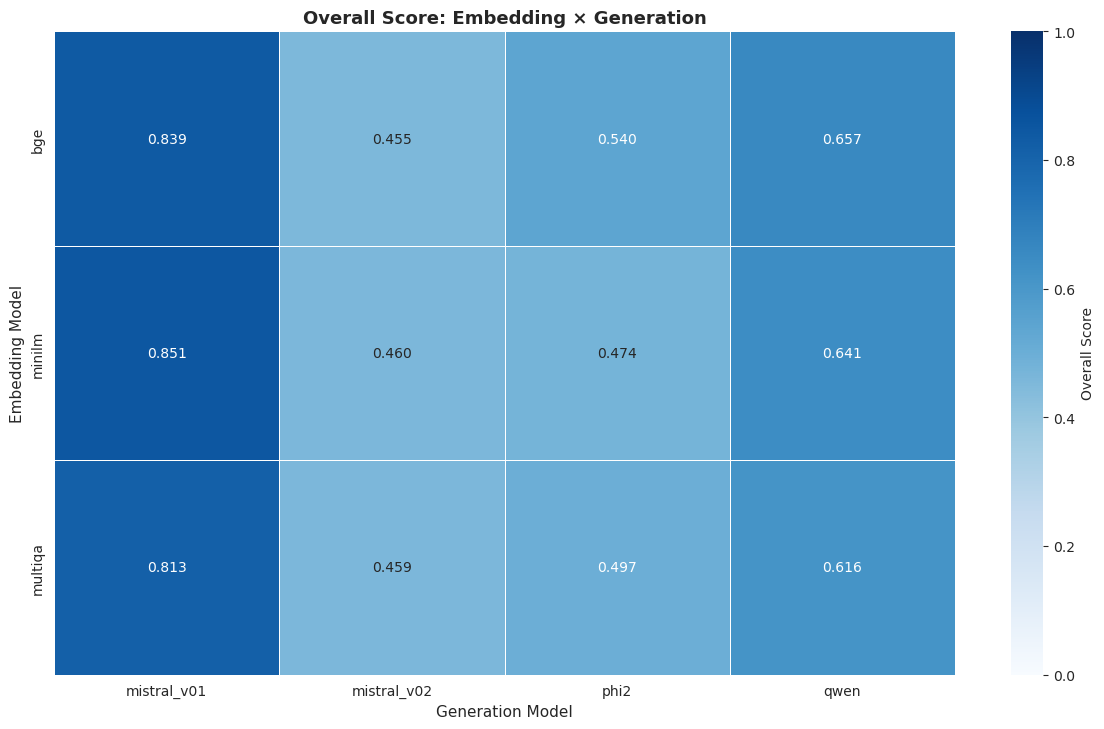




................................................................................
BEST CONFIGURATION PER METRIC
................................................................................

  Entity-F1                : minilm_mistral_v01              (0.8324)  [higher is better]
  Token-F1                 : minilm_mistral_v01              (0.8083)  [higher is better]
  Cosine Similarity        : minilm_mistral_v01              (0.8730)  [higher is better]
  Semantic Similarity      : minilm_mistral_v01              (0.8730)  [higher is better]
  Answer Relevance         : bge_qwen                        (0.6727)  [higher is better]
  Hallucination            : minilm_mistral_v01              (0.0947)  [lower is better]
  Faithfulness             : minilm_mistral_v01              (0.8859)  [higher is better]
  Completeness             : minilm_mistral_v01              (0.8291)  [higher is better]
  Key Info                 : minilm_mistral_v01              (0.8570)  [higher is bet

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

# Set style for publication-quality plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# ============================================================================
# CONFIGURATION
# ============================================================================

EMBEDDINGS = {
    'minilm':  'all-MiniLM-L6-v2',
    'bge':     'BAAI/bge-base-en-v1.5',
    'multiqa': 'sentence-transformers/multi-qa-mpnet-base-dot-v1',
}

GENERATIONS = {
    'mistral_v01': 'mistralai/Mistral-7B-v0.1',
    'mistral_v02': 'mistralai/Mistral-7B-Instruct-v0.2',
    'phi2':        'microsoft/phi-2',
    'qwen':        'Qwen/Qwen2.5-7B-Instruct',
}

METRICS = [
    'Entity-F1', 'Token-F1', 'Cosine Similarity', 'Semantic Similarity',
    'Answer Relevance', 'Hallucination', 'Faithfulness', 'Completeness',
    'Key Info', 'Exact Match', 'Latency (s)',
]

LOWER_IS_BETTER = {'Hallucination', 'Latency (s)'}


# ============================================================================
# MAIN ANALYZER CLASS
# ============================================================================

class RAGResultsAnalyzer:
    """Analyze RAG evaluation results for thesis"""

    def __init__(self, results_dir: str, output_dir: str = './analysis_output'):
        self.results_dir = Path(results_dir)
        self.output_dir  = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)

        self.results_df = self._load_all_results()
        print(f"Loaded {len(self.results_df)} total results")
        print(f"Configurations: {self.results_df['config'].nunique()}")

    def _load_all_results(self) -> pd.DataFrame:
        all_data  = []
        csv_files = list(self.results_dir.glob("query_expansion_*.csv"))
        print(f"\nLoading {len(csv_files)} result files...")

        for csv_file in csv_files:
            filename  = csv_file.stem
            parts     = filename.replace('query_expansion_', '').replace('_results', '').split('_')

            if len(parts) >= 2:
                emb_model = parts[0]
                gen_model = '_'.join(parts[1:])

                df = pd.read_csv(csv_file)
                df['embedding_model'] = emb_model
                df['generation_model'] = gen_model
                df['config'] = f"{emb_model}_{gen_model}"

                all_data.append(df)
                print(f"  {csv_file.name}: {len(df)} rows")

        return pd.concat(all_data, ignore_index=True)

    # ── Helpers ─────────────────────────────────────────────────────────────

    def _overall_score(self, df) -> tuple:
        """
        Returns (overall, gen_quality, faithfulness, completeness)
        Overall = 0.40 * gen_quality + 0.35 * faithfulness + 0.25 * completeness
        """
        gen_components = []
        for col in ['Entity-F1', 'Token-F1', 'Semantic Similarity']:
            if col in df.columns:
                gen_components.append(df[col].mean())
        gen_quality = np.mean(gen_components) if gen_components else 0

        faith_components = []
        if 'Faithfulness' in df.columns:
            faith_components.append(df['Faithfulness'].mean())
        if 'Hallucination' in df.columns:
            faith_components.append(1 - df['Hallucination'].mean())
        if 'Key Info' in df.columns:
            faith_components.append(df['Key Info'].mean())
        faithfulness = np.mean(faith_components) if faith_components else 0

        completeness = df['Completeness'].mean() if 'Completeness' in df.columns else 0
        overall      = 0.4 * gen_quality + 0.35 * faithfulness + 0.25 * completeness

        return overall, gen_quality, faithfulness, completeness

    def _fmt(self, df, col):
        if col not in df.columns:
            return 'N/A'
        return f"{df[col].mean():.3f}"

    # ========================================================================
    # 1. SUMMARY STATISTICS
    # ========================================================================

    def create_summary_table(self) -> pd.DataFrame:

        summary_data = []

        for config in sorted(self.results_df['config'].unique()):
            config_df = self.results_df[self.results_df['config'] == config]

            row = {
                'Configuration': config,
                'Embedding':     config_df['embedding_model'].iloc[0],
                'Generation':    config_df['generation_model'].iloc[0],
                'N':             len(config_df),
            }

            for metric in METRICS:
                if metric in config_df.columns:
                    row[f"{metric}_mean"] = config_df[metric].mean()
                    row[f"{metric}_std"]  = config_df[metric].std()

            summary_data.append(row)

        summary_df  = pd.DataFrame(summary_data)
        output_path = self.output_dir / "summary_statistics.csv"
        summary_df.to_csv(output_path, index=False)
        print(f"Saved: {output_path}")
        return summary_df

    # ========================================================================
    # 2. READABLE SUMMARY  →  ANSWER QUALITY ANALYSIS
    # ========================================================================

    def create_readable_summary(self) -> pd.DataFrame:

        rows = []

        for config in sorted(self.results_df['config'].unique()):
            cdf           = self.results_df[self.results_df['config'] == config]
            o, gq, fa, co = self._overall_score(cdf)

            rows.append({
                'Embedding':           cdf['embedding_model'].iloc[0],
                'Generation':          cdf['generation_model'].iloc[0],
                'Overall Score':       f"{o:.3f}",
                'Entity-F1':           self._fmt(cdf, 'Entity-F1'),
                'Token-F1':            self._fmt(cdf, 'Token-F1'),
                'Semantic Similarity': self._fmt(cdf, 'Semantic Similarity'),
                'Hallucination':       self._fmt(cdf, 'Hallucination'),
                'Faithfulness':        self._fmt(cdf, 'Faithfulness'),
                'Latency (s)':         self._fmt(cdf, 'Latency (s)'),
                '_sort':               o,
            })

        summary_df = (pd.DataFrame(rows)
                        .sort_values('_sort', ascending=False)
                        .drop(columns=['_sort']))

        output_path = self.output_dir / "summary_readable.csv"
        summary_df.to_csv(output_path, index=False)

        print("\n\n\n" + "."*80)
        print("ANSWER QUALITY ANALYSIS (sorted by Overall Score high to low)")
        print("Overall = 0.40 x Gen Quality  +  0.35 x Faithfulness  +  0.25 x Completeness")
        print("."*80)
        print()
        print(summary_df.to_string(index=False))
        print(f"\nSaved: {output_path}")
        print("."*80 + "\n\n\n")

        return summary_df

    # ========================================================================
    # 3. OVERALL SCORE HEATMAP
    # ========================================================================

    def plot_overall_score_heatmap(self):

        rows = []
        for config in sorted(self.results_df['config'].unique()):
            cdf   = self.results_df[self.results_df['config'] == config]
            o, *_ = self._overall_score(cdf)
            rows.append({
                'embedding_model':  cdf['embedding_model'].iloc[0],
                'generation_model': cdf['generation_model'].iloc[0],
                'overall_score':    round(o, 4),
            })

        pivot = (pd.DataFrame(rows)
                   .pivot(index='embedding_model',
                          columns='generation_model',
                          values='overall_score'))

        fig, ax = plt.subplots(figsize=(max(6, len(pivot.columns)*2.5 + 2),
                                        max(4, len(pivot.index)*1.8 + 2)))

        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='Blues',
                    vmin=0, vmax=1, ax=ax,
                    linewidths=0.5, linecolor='white',
                    cbar_kws={'label': 'Overall Score'})

        ax.set_title('Overall Score: Embedding × Generation', fontsize=13, fontweight='bold')
        ax.set_xlabel('Generation Model', fontsize=11)
        ax.set_ylabel('Embedding Model',  fontsize=11)
        plt.tight_layout()

        path = self.output_dir / 'heatmap_overall_score.png'
        plt.savefig(path, dpi=300, bbox_inches='tight')
        print(f"Saved: {path}")
        plt.show()
        plt.close()

    # ========================================================================
    # 4. BEST CONFIGURATION FINDER
    # ========================================================================

    def find_best_configurations(self) -> pd.DataFrame:

        print("\n\n\n" + "."*80)
        print("BEST CONFIGURATION PER METRIC")
        print("."*80)
        print()

        best_configs = []

        for metric in METRICS:
            if metric not in self.results_df.columns:
                continue

            grouped = self.results_df.groupby('config')[metric].mean()

            if metric in LOWER_IS_BETTER:
                best_config = grouped.idxmin()
                best_value  = grouped.min()
                direction   = 'lower is better'
            else:
                best_config = grouped.idxmax()
                best_value  = grouped.max()
                direction   = 'higher is better'

            print(f"  {metric:<25s}: {best_config:<30s}  ({best_value:.4f})  [{direction}]")

            best_configs.append({
                'Metric':             metric,
                'Best Configuration': best_config,
                'Best Value':         round(best_value, 4),
                'Direction':          direction,
            })

        best_df     = pd.DataFrame(best_configs)
        output_path = self.output_dir / "best_configurations.csv"
        best_df.to_csv(output_path, index=False)
        print(f"\nSaved: {output_path}")
        print("."*80 + "\n\n\n")

        return best_df

    # ========================================================================
    # 5. EMBEDDING MODEL COMPARISON  (pivot table)
    # ========================================================================

    def compare_embedding_models(self) -> pd.DataFrame:

        print("\n\n\n" + "-"*70)
        print("EMBEDDING MODEL COMPARISON")
        print("Rows = Embedding models | Columns = Generation models")
        print("Cell = overall_score for that (embedding, generation) config")
        print("OVERALL = mean across all generation partners")
        print("-"*70)
        print()

        rows = []
        for config in sorted(self.results_df['config'].unique()):
            cdf   = self.results_df[self.results_df['config'] == config]
            o, *_ = self._overall_score(cdf)
            rows.append({
                'embedding_model':  cdf['embedding_model'].iloc[0],
                'generation_model': cdf['generation_model'].iloc[0],
                'overall_score':    round(o, 4),
            })

        emb_table = (pd.DataFrame(rows)
                       .pivot(index='embedding_model',
                              columns='generation_model',
                              values='overall_score'))
        emb_table['OVERALL'] = emb_table.mean(axis=1).round(4)
        emb_table = emb_table.sort_values('OVERALL', ascending=False)

        print(emb_table.to_string())

        output_path = self.output_dir / "embedding_pivot_table.csv"
        emb_table.to_csv(output_path)
        print(f"\nSaved: {output_path}")
        print("-"*70 + "\n\n\n")

        return emb_table

    # ========================================================================
    # 6. GENERATION MODEL COMPARISON  (pivot table)
    # ========================================================================

    def compare_generation_models(self) -> pd.DataFrame:

        print("\n\n\n" + "="*70)
        print("GENERATION MODEL COMPARISON")
        print("Rows = Generation models | Columns = Embedding models")
        print("Cell = overall_score for that (embedding, generation) config")
        print("OVERALL = mean across all embedding partners")
        print("="*70)
        print()

        rows = []
        for config in sorted(self.results_df['config'].unique()):
            cdf   = self.results_df[self.results_df['config'] == config]
            o, *_ = self._overall_score(cdf)
            rows.append({
                'embedding_model':  cdf['embedding_model'].iloc[0],
                'generation_model': cdf['generation_model'].iloc[0],
                'overall_score':    round(o, 4),
            })

        gen_table = (pd.DataFrame(rows)
                       .pivot(index='generation_model',
                              columns='embedding_model',
                              values='overall_score'))
        gen_table['OVERALL'] = gen_table.mean(axis=1).round(4)
        gen_table = gen_table.sort_values('OVERALL', ascending=False)

        print(gen_table.to_string())

        output_path = self.output_dir / "generation_pivot_table.csv"
        gen_table.to_csv(output_path)
        print(f"\nSaved: {output_path}")
        print("="*70 + "\n\n\n")

        return gen_table

    # ========================================================================
    # 7. STATISTICAL COMPARISON
    # ========================================================================

    def compare_configurations(self, config1: str, config2: str) -> pd.DataFrame:

        print(f"\n\n\n" + "."*80)
        print(f"COMPARING: {config1}  vs  {config2}")
        print("."*80)
        print()

        df1 = self.results_df[self.results_df['config'] == config1]
        df2 = self.results_df[self.results_df['config'] == config2]

        if len(df1) == 0 or len(df2) == 0:
            print("ERROR: One or both configurations not found!")
            return pd.DataFrame()

        print(f"  {'Metric':<25} {config1:<20} {config2:<20} {'Diff':<10} {'p-value':<10} Sig?")
        print("  " + "-"*85)

        comparison = []

        for metric in METRICS:
            if metric not in df1.columns or metric not in df2.columns:
                continue

            v1 = df1[metric].values
            v2 = df2[metric].values

            t_stat, p_value = stats.ttest_rel(v1, v2)
            mean1, mean2    = v1.mean(), v2.mean()
            diff            = mean1 - mean2
            sig             = "✓" if p_value < 0.05 else ""

            print(f"  {metric:<25} {mean1:>6.3f} ± {v1.std():.3f}   "
                  f"{mean2:>6.3f} ± {v2.std():.3f}   {diff:>+7.3f}   {p_value:>8.4f}  {sig}")

            comparison.append({
                'Metric':               metric,
                f'{config1}_mean':      mean1,
                f'{config1}_std':       v1.std(),
                f'{config2}_mean':      mean2,
                f'{config2}_std':       v2.std(),
                'Difference':           diff,
                'p_value':              p_value,
                'Significant (p<0.05)': p_value < 0.05,
            })

        comparison_df = pd.DataFrame(comparison)
        output_path   = self.output_dir / f"comparison_{config1}_vs_{config2}.csv"
        comparison_df.to_csv(output_path, index=False)
        print(f"\nSaved: {output_path}")
        print("."*80 + "\n\n\n")

        return comparison_df

    # ========================================================================
    # 8. ALL METRIC HEATMAPS
    # ========================================================================

    def plot_heatmap(self, metric: str):

        pivot = (self.results_df
                 .groupby(['embedding_model', 'generation_model'])[metric]
                 .mean()
                 .unstack())

        cmap = 'RdYlGn_r' if metric in LOWER_IS_BETTER else 'RdYlGn'

        plt.figure(figsize=(max(8, len(pivot.columns)*2.5 + 2),
                            max(4, len(pivot.index)*1.5 + 2)))
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmap,
                    vmin=0, vmax=1, cbar_kws={'label': metric},
                    linewidths=0.5, linecolor='white')
        plt.title(f'{metric} Across Model Combinations', fontsize=14, fontweight='bold')
        plt.xlabel('Generation Model', fontsize=12)
        plt.ylabel('Embedding Model',  fontsize=12)
        plt.tight_layout()

        output_path = self.output_dir / f"heatmap_{metric.replace(' ', '_').lower()}.png"
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"  Saved: {output_path}")
        plt.close()

    def plot_all_heatmaps(self):
        print("\n\n\n" + "."*80)
        print("GENERATING HEATMAPS")
        print("."*80)

        key_metrics = [
            'Semantic Similarity', 'Faithfulness', 'Answer Relevance',
            'Hallucination', 'Completeness',
        ]
        for metric in key_metrics:
            if metric in self.results_df.columns:
                self.plot_heatmap(metric)

        print("."*80 + "\n\n\n")

    # ========================================================================
    # 9. BAR CHARTS
    # ========================================================================

    def plot_comparison_bars(self):
        print("\n\n\n" + "."*80)
        print("GENERATING BAR CHARTS")
        print("."*80)

        key_metrics = ['Semantic Similarity', 'Faithfulness', 'Answer Relevance']

        # Embedding comparison
        emb_data = []
        for emb in EMBEDDINGS.keys():
            edf = self.results_df[self.results_df['embedding_model'] == emb]
            if len(edf) > 0:
                row = {'Model': emb}
                for m in key_metrics:
                    if m in edf.columns:
                        row[m] = edf[m].mean()
                emb_data.append(row)

        if emb_data:
            fig, ax = plt.subplots(figsize=(10, 6))
            pd.DataFrame(emb_data).set_index('Model')[key_metrics].plot(kind='bar', ax=ax, width=0.8)
            plt.title('Embedding Model Performance Comparison', fontsize=14, fontweight='bold')
            plt.ylabel('Score', fontsize=12)
            plt.xlabel('Embedding Model', fontsize=12)
            plt.legend(title='Metric')
            plt.xticks(rotation=0)
            plt.tight_layout()
            path = self.output_dir / "embedding_comparison_bars.png"
            plt.savefig(path, dpi=300, bbox_inches='tight')
            print(f"Saved: {path}")
            plt.close()

        # Generation comparison
        gen_data = []
        for gen in GENERATIONS.keys():
            gdf = self.results_df[self.results_df['generation_model'] == gen]
            if len(gdf) > 0:
                row = {'Model': gen}
                for m in key_metrics:
                    if m in gdf.columns:
                        row[m] = gdf[m].mean()
                gen_data.append(row)

        if gen_data:
            fig, ax = plt.subplots(figsize=(10, 6))
            pd.DataFrame(gen_data).set_index('Model')[key_metrics].plot(kind='bar', ax=ax, width=0.8)
            plt.title('Generation Model Performance Comparison', fontsize=14, fontweight='bold')
            plt.ylabel('Score', fontsize=12)
            plt.xlabel('Generation Model', fontsize=12)
            plt.legend(title='Metric')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            path = self.output_dir / "generation_comparison_bars.png"
            plt.savefig(path, dpi=300, bbox_inches='tight')
            print(f"Saved: {path}")
            plt.close()

        print("."*80 + "\n\n\n")

    # ========================================================================
    # 10. GENERATE COMPLETE REPORT
    # ========================================================================

    def generate_complete_report(self):

        print("\n\n\n" + "="*80)
        print("GENERATING COMPLETE ANALYSIS REPORT")
        print("="*80)

        self.create_summary_table()
        self.create_readable_summary()        # prints ANSWER QUALITY ANALYSIS table
        self.plot_overall_score_heatmap()     # displays heatmap right after table
        self.find_best_configurations()
        self.compare_embedding_models()
        self.compare_generation_models()
        self.plot_all_heatmaps()
        self.plot_comparison_bars()
        self._create_text_report()

        print("\n" + "="*80)
        print(f"COMPLETE! All analysis files saved to: {self.output_dir}")
        print("="*80)

    def _create_text_report(self):

        report_path = self.output_dir / "analysis_report.txt"

        with open(report_path, 'w') as f:
            f.write("="*80 + "\n")
            f.write("RAG EVALUATION ANALYSIS REPORT\n")
            f.write("="*80 + "\n\n")
            f.write(f"Total Configurations Tested: {self.results_df['config'].nunique()}\n")
            f.write(f"Total Test Cases per Config: "
                    f"{len(self.results_df) // self.results_df['config'].nunique()}\n\n")
            f.write("Embedding Models:\n")
            for emb, full_name in EMBEDDINGS.items():
                f.write(f"  - {emb}: {full_name}\n")
            f.write("\nGeneration Models:\n")
            for gen, full_name in GENERATIONS.items():
                f.write(f"  - {gen}: {full_name}\n")
            f.write("\n" + "="*80 + "\n")
            f.write("OUTPUTS GENERATED\n")
            f.write("="*80 + "\n")
            f.write("1. summary_statistics.csv\n")
            f.write("2. summary_readable.csv\n")
            f.write("3. heatmap_overall_score.png\n")
            f.write("4. best_configurations.csv\n")
            f.write("5. embedding_pivot_table.csv\n")
            f.write("6. generation_pivot_table.csv\n")
            f.write("7. Metric heatmaps (PNG files)\n")
            f.write("8. Bar charts (PNG files)\n")

        print(f"Text report saved: {report_path}")


# ============================================================================
# MAIN
# ============================================================================

if __name__ == "__main__":

    RESULTS_DIR = "evaluation_results/query_expansion/"
    OUTPUT_DIR  = "results_analysis/query_expansion/"

    analyzer = RAGResultsAnalyzer(
        results_dir=RESULTS_DIR,
        output_dir=OUTPUT_DIR,
    )

    analyzer.generate_complete_report()

    print("\nAnalysis complete!")
    print(f"Check {OUTPUT_DIR} for all results")

In [1]:
import pandas as pd
import numpy as np
import os

def analyze_worst_questions(input_csv: str, output_csv: str, n_worst: int = 20):
    """
    Extract worst performing questions based on overall score
    
    Args:
        input_csv: Path to input CSV file with evaluation results
        output_csv: Path to save output CSV file
        n_worst: Number of worst questions to extract (default: 30)
    
    Returns:
        DataFrame with worst questions
    """
    print("\n" + "="*80)
    print(f"EXTRACTING {n_worst} WORST PERFORMING QUESTIONS")
    print("="*80)
    print(f"Input: {input_csv}")
    print(f"Output: {output_csv}\n")
    
    # Check if input file exists
    if not os.path.exists(input_csv):
        print(f"❌ Error: File not found: {input_csv}")
        return None
    
    # Load data
    print("Loading data...")
    df = pd.read_csv(input_csv)
    print(f"✓ Loaded {len(df)} questions\n")
    
    # Calculate overall score
    print("Calculating overall scores...")
    
    # Generation Quality (40%): Entity-F1, Token-F1, Semantic Similarity
    gen_quality = (
        df['Entity-F1'] + 
        df['Token-F1'] + 
        df['Semantic Similarity']
    ) / 3
    
    # Faithfulness (35%): Faithfulness, (1 - Hallucination), Key Info
    faithfulness_score = (
        df['Faithfulness'] + 
        (1 - df['Hallucination']) + 
        df['Key Info']
    ) / 3
    
    # Completeness (25%)
    completeness_score = df['Completeness']
    
    # Overall Score
    df['overall_score'] = (
        0.40 * gen_quality + 
        0.35 * faithfulness_score + 
        0.25 * completeness_score
    )
    
    print(f"✓ Overall scores calculated")
    print(f"  Mean: {df['overall_score'].mean():.3f}")
    print(f"  Min:  {df['overall_score'].min():.3f}")
    print(f"  Max:  {df['overall_score'].max():.3f}\n")
    
    # Sort by overall_score (ascending = worst first)
    df_sorted = df.sort_values('overall_score', ascending=True)
    
    # Get worst N questions
    worst_df = df_sorted.head(n_worst).copy()
    
    # Try different column name variations
    question_col = 'question' if 'question' in worst_df.columns else 'Question'
    expected_col = 'expected_answer' if 'expected_answer' in worst_df.columns else 'Expected Answer'
    generated_col = 'actual_answer' if 'actual_answer' in worst_df.columns else 'Actual Answer'
    
    # Get original index
    original_indices = worst_df.index.tolist()
    overall_scores = worst_df['overall_score'].values
    
    # Create clean output with only 3 columns
    output_df = pd.DataFrame({
        'Question Index': original_indices,
        'Overall Score': overall_scores,
        'Question': worst_df[question_col].values,
        'Expected Answer': worst_df[expected_col].values,
        'Generated Answer': worst_df[generated_col].values,
    })
    
    # Save to CSV
    os.makedirs(os.path.dirname(output_csv), exist_ok=True)
    output_df.to_csv(output_csv, index=False)
    print(f"✓ Saved {len(output_df)} worst questions to: {output_csv}\n")
    
    # Print preview
    print("="*80)
    print("TOP 5 WORST QUESTIONS PREVIEW")
    print("="*80)
    
    for idx in range(min(20, len(output_df))):
        print(f"\n#{idx + 1} | Question Index: {output_df.iloc[idx]['Question Index']} | Overall Score: {output_df.iloc[idx]['Overall Score']:.3f}")
        print("-" * 80)
        print(f"Question:\n{output_df.iloc[idx]['Question']}\n")
        print(f"Expected Answer:\n{output_df.iloc[idx]['Expected Answer']}\n")
        print(f"Generated Answer:\n{output_df.iloc[idx]['Generated Answer']}\n")
    
    print("="*80)
    print("✓ ANALYSIS COMPLETE!")
    print("="*80 + "\n")
    
    return output_df

# ============================================================================
# USAGE EXAMPLE
# ============================================================================
if __name__ == "__main__":
    # Example usage
    worst_questions = analyze_worst_questions(
        input_csv='evaluation_results/query_expansion/query_expansion_minilm_mistral_v01_results.csv',
        output_csv='evaluation_results/query_expansion/query_expansion_minilm_mistral_v01_worst_questions.csv',
        n_worst=20
    )


EXTRACTING 20 WORST PERFORMING QUESTIONS
Input: evaluation_results/query_expansion/query_expansion_minilm_mistral_v01_results.csv
Output: evaluation_results/query_expansion/query_expansion_minilm_mistral_v01_worst_30_questions.csv

Loading data...
✓ Loaded 100 questions

Calculating overall scores...
✓ Overall scores calculated
  Mean: 0.842
  Min:  0.034
  Max:  1.000

✓ Saved 20 worst questions to: evaluation_results/query_expansion/query_expansion_minilm_mistral_v01_worst_30_questions.csv

TOP 5 WORST QUESTIONS PREVIEW

#1 | Question Index: 25 | Overall Score: 0.034
--------------------------------------------------------------------------------
Question:
What is the application deadlines for bachelor programs?

Expected Answer:
Application deadlines vary by program. Please specify which program.

Generated Answer:
Here are the programs (Bachelor level):

  - Business Administration B.A.
  - Business Information Systems B.Sc.
  - Business Law LL.B.
  - Computer Science (B.Sc.)
  - 